# 英语 → 西班牙语机器翻译 —— Seq2Seq + Bahdanau Attention（Seq2Seq.md）

本 Notebook 使用 PyTorch 完成英语到西班牙语的神经机器翻译任务，采用 Seq2Seq + Bahdanau 注意力架构。主要内容：

1. 文本预处理（去重音、分离标点、统一大小写）
2. 制作 Dataset（读取 spa.txt 并按 9:1 划分训练/测试集）
3. Tokenizer 构建（词典 + BOS/EOS + 动态 Padding）
4. DataLoader 构建（Teacher Forcing 与 padding mask）
5. Encoder 编码器（单向 GRU）
6. Bahdanau Attention 注意力机制
7. Decoder 解码器（带注意力的 GRU）
8. 搭建 Seq2Seq 总模型（forward 训练 + infer 推理）
9. 编写损失函数（忽略 PAD 的交叉熵）
10. 训练与评估
11. 注意力热力图可视化
12. BLEU 指标评估

数据文件：`data/spa.txt`（每行用制表符分隔英文与西班牙语）。


## 1. 预处理 —— 文本清洗与规范化

先把带重音的字符（á、ñ、é 等）规范化为基础 ASCII 字符，再把标点与单词分开、统一大小写与空白，减小词表复杂度。


In [1]:
# 英语和西班牙语的数据中经常会出现一些带有重音或变音符号的字符（比如西班牙语中的á、ñ，法语中的é等），这些字符会影响后续的文本标准化、分词和词汇表构建。
# 为了简化处理流程，我们常常会将所有字符转换为ASCII编码，也就是去除掉重音或者特殊符号，使不同写法统一到同一个标准字符。
# 这样可以减少词汇表的复杂性，有助于模型更快收敛、降低过拟合风险，尤其是在只关注语义、不关心拼写细节的机器翻译场景。
import unicodedata  # Unicode 工具，用于去除字符重音
import re  # 正则表达式工具，用于清洗文本


def unicode_to_ascii(s):
    """
    去除重音符号，将 Unicode 文本规范化为基础 ASCII 字符

    原理: NFD 规范化把字符拆成“基础字符 + 组合变音符号(Mn)”，
    过滤掉 Mn 类别即可得到无重音的基础字符。
    """
    # NFD将字符串的每个字符拆分为基础字符和所有的重音符号/修饰 (Normalize Form D)
    # Mn表示所有的Nonspacing_Mark（即重音符等），这里将这些去除，实现ascii化
    return ''.join(  # 用 join 把保留的字符拼回字符串
        c for c in unicodedata.normalize('NFD', s)  # NFD 拆分出基础字符与组合变音符号
        if unicodedata.category(c) != 'Mn'  # 过滤掉组合变音符号(Mn)类别
    )


# 举个例子，西班牙语和英文都有不同特殊字符
# 将字符串转为ASCII可以消除如 ¿, á, é, ñ 等带重音/特殊字符的差异，统一到基础字母
en_sentence = u"May I borrow, this book?"  # 英文示例句
sp_sentence = u"¿Puedo tomar prestado este libro?"  # 西语示例句

print(unicode_to_ascii(en_sentence))  # May I borrow, this book?
print(unicode_to_ascii(sp_sentence))  # ¿Puedo tomar prestado este libro?

May I borrow, this book?
¿Puedo tomar prestado este libro?


In [2]:
def preprocess_sentence(w):
    """
    w是某一个样本的句子

    参数:
        w: 原始句子字符串
    返回:
        清洗后的句子字符串
    """
    #变为小写，去掉多余的空格，变成小写，id少一些
    w = unicode_to_ascii(w.lower().strip())  # 小写 + 去重音 + 去首尾空白

    # 在单词与跟在其后的 标点符号?.!,¿ 之间插入一个空格
    # eg: "he is a boy." => "he is a boy . "
    # Reference:- https://stackoverflow.com/questions/3645931/python-padding-punctuation-with-white-spaces-keeping-punctuation
    w = re.sub(r"([?.!,¿])", r" \1 ", w)  # 标点两侧加空格，独立成 token

    # 除了 (a-z, A-Z, ".", "?", "!", ",")，将所有字符替换为空格，你可以保留一些标点符号
    w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)  # 非字母/标点字符替换为空格

    #因为可能有多余空格，替换为一个空格，所以处理一下
    w = re.sub(r'[" "]+', " ", w)  # 连续空格合并为一个

    w = w.strip()  #strip是去掉两边的空格

    return w  # 返回清洗后的句子


# 用 preprocess_sentence 处理上面定义的两个句子
print(preprocess_sentence(en_sentence))  # May i borrow , this book ?
print(preprocess_sentence(sp_sentence))  # ? puedo tomar prestado este libro ?

may i borrow , this book ?
¿ puedo tomar prestado este libro ?


## 2. 制作 Dataset —— 数据加载与划分

读取 `data/spa.txt`，打乱后按 9:1 划分训练/测试集；`TranslationDataset` 在取样时对句子做预处理。


In [3]:
import numpy as np  # 数值计算库，用于数据打乱

# 读取 data/spa.txt 文件
path_to_file = 'data/spa.txt'  # 英语—西班牙语平行语料路径
# 读取所有行
with open(path_to_file, encoding='utf-8') as f:
    lines = f.read().strip().split('\n')  # 去掉首尾空行并按行拆分

# 每一行分为英文和西班牙语
word_pairs = []  # (英文, 西班牙语) 句对列表
for l in lines:  # 逐行处理
    en, sp = l.split('\t')  # 按制表符拆分英文与西语
    word_pairs.append((en, sp))  # 保存当前句对

# 打乱数据
np.random.seed(42)  # 固定随机种子，保证可复现
np.random.shuffle(word_pairs)  # 打乱句对顺序

# 9:1 划分训练集和测试集
n_total = len(word_pairs)  # 总样本数
n_train = int(n_total * 0.9)  # 训练集样本数（90%）
train_pairs = word_pairs[:n_train]  # 前 90% 作为训练集
test_pairs = word_pairs[n_train:]  # 后 10% 作为测试集

# 制作Dataset（这里只是生成分好train/test的样本对清单，后续可以根据模型需要做进一步处理）
print(f"总样本数: {n_total}, 训练集: {len(train_pairs)}，测试集: {len(test_pairs)}")  # 打印划分结果
print("训练集样本举例：")  # 打印训练集样例标题
for i in range(3):  # 打印前 3 条训练样本
    print(train_pairs[i])  # 打印第 i 条训练样本
print("测试集样本举例：")  # 打印测试集样例标题
for i in range(3):  # 打印前 3 条测试样本
    print(test_pairs[i])  # 打印第 i 条测试样本

总样本数: 118964, 训练集: 107067，测试集: 11897
训练集样本举例：
('How boring!', '¡Qué aburrimiento!')
('I love sports.', 'Adoro el deporte.')
('Would you like to swap jobs?', '¿Te gustaría que intercambiemos los trabajos?')
测试集样本举例：
('Even Tom has his doubts.', 'Incluso Tomás tiene sus dudas.')
('Who can speak French better, Tom or Mary?', '¿Quién sabe hablar francés mejor: Tom o Mary?')
('Tom came just before dinner.', 'Tom vino justo antes de la cena.')


In [4]:
class TranslationDataset:
    """
    翻译数据集: 保存 (英文, 西班牙语) 句对清单

    取样时对句子做预处理（去重音、分离标点），返回 (西班牙语, 英语)。
    数值化与 Padding 放到 DataLoader 的 collate_fn 中完成。
    """

    def __init__(self, pairs):  # 初始化: 保存句对清单
        self.pairs = pairs  # 保存句对清单 [(英文, 西班牙语), ...]

    def __len__(self):  # 返回样本总数
        return len(self.pairs)  # 样本总数

    def __getitem__(self, idx):  # 按索引取一条句对并预处理
        en, sp = self.pairs[idx]  # 取出第 idx 条句对
        # 返回（西班牙语，英语），均经过 preprocess_sentence 处理
        return preprocess_sentence(sp), preprocess_sentence(en)


# 示例：创建训练集、测试集的Dataset对象，并取样结果
train_dataset = TranslationDataset(train_pairs)  # 训练集 Dataset
test_dataset = TranslationDataset(test_pairs)  # 测试集 Dataset

print("Dataset 取样结果举例：")  # 打印取样标题
for i in range(3):  # 打印前 3 条样本
    sp, en = train_dataset[i]  # 取样得到 (西班牙语, 英语)
    print(f"西班牙语: {sp}\n英语: {en}\n")  # 打印西语与英语

Dataset 取样结果举例：
西班牙语: que aburrimiento !
英语: how boring !

西班牙语: adoro el deporte .
英语: i love sports .

西班牙语: ¿ te gustaria que intercambiemos los trabajos ?
英语: would you like to swap jobs ?



## 3. Tokenizer 构建 —— 词典与编码解码

基于训练集构建英语/西班牙语词典（PAD/UNK/BOS/EOS + 词表）；`Tokenizer` 负责编码（加 BOS/EOS + 动态 Padding）与解码。


In [5]:
# 基于训练集构建英语和西班牙语的词典（tokenizer/vocab）
from collections import Counter  # 词频统计容器


def build_vocab(sentences, min_freq=1):
    """
    根据句子列表构建词典

    参数:
        sentences:  句子字符串列表
        min_freq:   词频阈值，低于该频率的词被丢弃（用 <UNK> 代替）
    返回:
        word2idx: 词 → ID 映射
        id2word:  ID → 词 映射
    """
    counter = Counter()  # 词频计数器
    for s in sentences:  # 逐句统计词频
        counter.update(s.split())  # 统计当前句子每个词的词频
    # 保留频率大于等于min_freq的词
    # 常规特殊符号: PAD, UNK, BOS, EOS
    vocab = ['<PAD>', '<UNK>', '<BOS>', '<EOS>'] + [w for w, c in counter.items() if c >= min_freq]
    word2idx = {w: i for i, w in enumerate(vocab)}  # 词 → ID
    id2word = {i: w for i, w in enumerate(vocab)}  # ID → 词
    return word2idx, id2word  # 返回词→ID 与 ID→词 两个映射


# 分别采集训练集中的西班牙语、英语句子
sp_sentences = []  # 西语句子列表
en_sentences = []  # 英语句子列表
for i in range(len(train_dataset)):  # 遍历训练集取句子
    sp, en = train_dataset[i]  # 取样得到 (西班牙语, 英语)
    sp_sentences.append(sp)  # 收集西语句子
    en_sentences.append(en)  # 收集英语句子

# 构建西班牙语和英语词典
sp_word2idx, sp_id2word = build_vocab(sp_sentences)  # 西语词典
en_word2idx, en_id2word = build_vocab(en_sentences)  # 英语词典

print(f"西班牙语词典大小: {len(sp_word2idx)}")  # 打印西语词典大小
print(f"英语词典大小: {len(en_word2idx)}")  # 打印英语词典大小

# 查看部分样例
print(f"西班牙语词表前10: {[sp_id2word[i] for i in range(10)]}")  # 打印西语词表前 10 词
print(f"英语词表前10: {[en_id2word[i] for i in range(10)]}")  # 打印英语词表前 10 词

西班牙语词典大小: 23754
英语词典大小: 12478
西班牙语词表前10: ['<PAD>', '<UNK>', '<BOS>', '<EOS>', 'que', 'aburrimiento', '!', 'adoro', 'el', 'deporte']
英语词表前10: ['<PAD>', '<UNK>', '<BOS>', '<EOS>', 'how', 'boring', '!', 'i', 'love', 'sports']


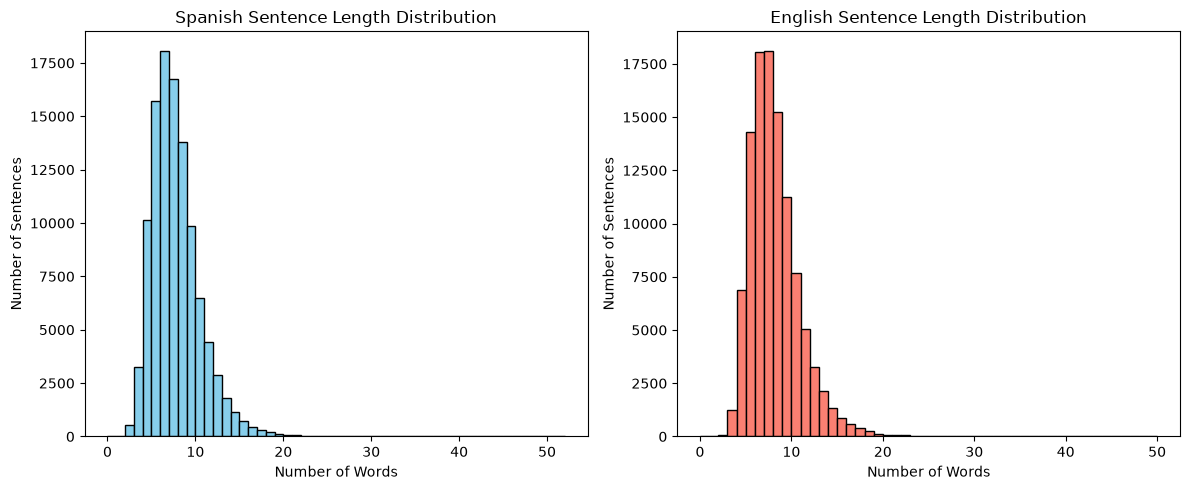

51
49


In [6]:
import matplotlib.pyplot as plt  # 绘图库，用于句长分布可视化

# 统计每个句子的词数（按空格分词），观察句长分布、决定 max_length 取值
sp_lens = [len(s.split()) for s in sp_sentences]  # 西语句长列表
en_lens = [len(s.split()) for s in en_sentences]  # 英语句长列表

plt.figure(figsize=(12, 5))  # 创建画布

plt.subplot(1, 2, 1)  # 子图1: 西语句长分布
plt.hist(sp_lens, bins=range(0, max(sp_lens) + 2, 1), color='skyblue', edgecolor='black')  # 绘制西语句长直方图
plt.title('Spanish Sentence Length Distribution')  # 子图标题
plt.xlabel('Number of Words')  # 横轴: 词数
plt.ylabel('Number of Sentences')  # 纵轴: 句子数

plt.subplot(1, 2, 2)  # 子图2: 英语句长分布
plt.hist(en_lens, bins=range(0, max(en_lens) + 2, 1), color='salmon', edgecolor='black')  # 绘制英语句长直方图
plt.title('English Sentence Length Distribution')  # 子图标题
plt.xlabel('Number of Words')  # 横轴: 词数
plt.ylabel('Number of Sentences')  # 纵轴: 句子数

plt.tight_layout()  # 自动调整布局
plt.show()  # 显示图像
print(max(sp_lens))  # 西语最大句长
print(max(en_lens))  # 英语最大句长

In [7]:
class Tokenizer:
    """
    分词器: 负责句子的编码（加 BOS/EOS + 动态 Padding）与解码

    encode: 句子列表 → 等长 token id 二维列表（短句补 PAD，超长截断）
    decode: token id 列表 → 去除特殊符号后的句子列表
    """

    def __init__(self, word2idx, id2word):  # 初始化: 保存映射与各特殊符号 id
        self.word2idx = word2idx  # 词 → ID
        self.id2word = id2word  # ID → 词
        self.pad_token = '<PAD>'  # 补齐符号
        self.unk_token = '<UNK>'  # 未知词符号
        self.bos_token = '<BOS>'  # 句首符号
        self.eos_token = '<EOS>'  # 句尾符号
        self.pad_idx = word2idx[self.pad_token]  # <PAD> 的 id
        self.unk_idx = word2idx[self.unk_token]  # <UNK> 的 id
        self.bos_idx = word2idx[self.bos_token]  # <BOS> 的 id
        self.eos_idx = word2idx[self.eos_token]  # <EOS> 的 id

    def encode(self, sentences, max_length=None, add_bos=True, add_eos=True, pad_side='right'):
        """
        输入: sentences 是一个批次（batch）的字符串列表。
        输出: 每个字符串对应的token id列表，带BOS/EOS并pad为定长。
        支持BOS/EOS/PAD加在左/右两侧的方式
        - pad_side: 'right'（右侧padding）或 'left'（左侧padding）
        - add_bos: 是否加BOS
        - add_eos: 是否加EOS
        返回: List[List[int]]
        """
        batch_ids = []  # 用于存放batch中所有句子的编码结果
        ids_list = []  # 保存未pad的id序列
        for sentence in sentences:  # 遍历batch中的每个句子
            tokens = sentence.split()  # 将句子按空格分词
            ids = []  # 当前句子的token id序列
            if add_bos:  # 是否加BOS符号
                ids.append(self.bos_idx)  # 加入BOS的索引
            ids.extend([self.word2idx.get(w, self.unk_idx) for w in tokens])  # 逐词查id，加UNK回退
            if add_eos:  # 是否加EOS符号
                ids.append(self.eos_idx)  # 加入EOS的索引
            ids_list.append(ids)  # 暂存未pad的结果

        # 计算本batch的最大长度
        pad_length = max(len(ids) for ids in ids_list)  # 本批最长句长度
        if max_length is not None:  # 若指定了最大长度
            pad_length = min(pad_length, max_length)  # 取实际长度与上限的较小值

        for ids in ids_list:  # 逐句补齐/截断
            if len(ids) < pad_length:  # 长度不足需要补齐
                pad_count = pad_length - len(ids)  # 需补 PAD 的个数
                if pad_side == 'right':  # 右侧补齐
                    ids = ids + [self.pad_idx] * pad_count  # 尾部追加 PAD
                elif pad_side == 'left':  # 左侧补齐
                    ids = [self.pad_idx] * pad_count + ids  # 头部插入 PAD
                else:  # 非法 pad_side
                    raise ValueError("pad_side 应为 'left' 或 'right'")  # 抛异常提示
            else:  # 超长则截断
                # 若超长则截断，保证BOS和EOS等在正确位置
                if pad_side == 'right':  # 右侧截断
                    ids = ids[:pad_length]  # 右侧截断
                    if add_eos and ids[-1] != self.eos_idx:  # 截断后末尾不是 EOS 则补上
                        ids[-1] = self.eos_idx  # 强制末位置为 EOS
                else:  # pad_side == 'left'
                    ids = ids[-pad_length:]  # 左侧截断
                    if add_eos and ids[-1] != self.eos_idx:  # 截断后末尾不是 EOS 则补上
                        ids[-1] = self.eos_idx  # 强制末位置为 EOS
            batch_ids.append(ids)  # 收集当前句的补齐结果
        return batch_ids  # 返回整批编码结果

    def decode(self, batch_ids, remove_special_tokens=True):
        """
        输入: batch_ids 是一个batch的token id列表（List[List[int]]）
        输出: 去除特殊符号的句子列表
        """
        results = []  # 存放还原后的句子
        for ids in batch_ids:  # 遍历每个句子的id序列
            tokens = []  # 当前句子的token串
            for idx in ids:  # 遍历该句子的每个token id
                token = self.id2word.get(idx, self.unk_token)  # 根据id查token
                if remove_special_tokens and token in {self.pad_token, self.bos_token, self.eos_token}:  # 跳过特殊token
                    continue  # 跳过该特殊 token
                tokens.append(token)  # 加入正常token
            results.append(' '.join(tokens))  # 合成还原后的句子
        return results  # 返回batch中全部解码句子


# 示例
sp_tokenizer = Tokenizer(sp_word2idx, sp_id2word)  # 西语 Tokenizer
en_tokenizer = Tokenizer(en_word2idx, en_id2word)  # 英语 Tokenizer

# 简单测试
sample_en = en_sentences[150:155]  # 取 5 条英语句子做演示
encoded_en = en_tokenizer.encode(sample_en, max_length=10)  # 编码（限制最大长度 10）
decoded_en = en_tokenizer.decode(encoded_en)  # 解码回文本
print(f"English sentence: {sample_en}")  # 打印原始句子
# 输出每个句子的原文、编码、解码结果上下对齐
for i in range(len(sample_en)):  # 逐条对照打印
    print(f"Original: {sample_en[i]}")  # 原文
    print(f"Encoded : {encoded_en[i]}")  # 编码 id
    print(f"Decoded : {decoded_en[i]}")  # 解码文本
    print('-' * 40)  # 分隔线

English sentence: ['do you like renaissance art ?', 'stop that car .', 'from this point , we ll go on foot .', 'tom had a very good time .', 'i told you i don t know if tom will tell the truth .']
Original: do you like renaissance art ?
Encoded : [2, 169, 12, 13, 405, 406, 17, 3, 0, 0]
Decoded : do you like renaissance art ?
----------------------------------------
Original: stop that car .
Encoded : [2, 292, 96, 262, 10, 3, 0, 0, 0, 0]
Decoded : stop that car .
----------------------------------------
Original: from this point , we ll go on foot .
Encoded : [2, 116, 120, 407, 168, 122, 408, 296, 409, 3]
Decoded : from this point , we ll go on
----------------------------------------
Original: tom had a very good time .
Encoded : [2, 43, 187, 35, 394, 286, 229, 10, 3, 0]
Decoded : tom had a very good time .
----------------------------------------
Original: i told you i don t know if tom will tell the truth .
Encoded : [2, 7, 242, 12, 7, 86, 57, 98, 88, 3]
Decoded : i told you i don t 

## 4. DataLoader 构建 —— Teacher Forcing 与 padding mask

`collate_fn` 把句对编码为张量并构造 Teacher Forcing 输入/输出；`make_padding_mask` 生成掩码，让 PAD 位置不参与损失。


In [8]:
import torch  # PyTorch 核心库
from torch.utils.data import DataLoader  # 批量加载器


def make_padding_mask(ids_tensor, pad_idx):
    """
    根据 token id 张量生成 padding mask。

    参数:
        ids_tensor: LongTensor, shape (batch_size, seq_len)
        pad_idx: PAD 对应的 id

    返回:
        mask: LongTensor, 1 表示有效 token，0 表示 PAD 位置
    """
    return (ids_tensor != pad_idx).long()  # 非 PAD 为 1，PAD 为 0


def create_collate_fn(src_tokenizer, tgt_tokenizer, max_enc_len=None, max_dec_len=None):
    """
    创建 DataLoader 的 collate_fn 回调函数。
    在组 batch 时将源语言、目标语言句子转为 id 张量，并构造 decoder 的 teacher forcing 输入/输出。

    参数:
        src_tokenizer: 源语言（西班牙语）Tokenizer
        tgt_tokenizer: 目标语言（英语）Tokenizer
        max_enc_len: encoder 最大序列长度，None 表示按 batch 内最长句动态 padding
        max_dec_len: decoder 最大序列长度，None 表示按 batch 内最长句动态 padding

    返回:
        collate_fn: 可供 DataLoader 使用的回调函数
    """

    def collate_fn(batch):
        """
        将一个 batch 的样本整理为 seq2seq 模型输入。

        参数:
            batch: [(src_sentence, tgt_sentence), ...] 列表

        返回:
            encoder_input: LongTensor, encoder 输入，shape (batch_size, enc_seq_len)
            decoder_input: LongTensor, decoder 输入（teacher forcing），shape (batch_size, dec_seq_len)
            decoder_output: LongTensor, decoder 标签/输出，shape (batch_size, dec_seq_len)
            encoder_mask: LongTensor, encoder padding mask，1=有效，0=PAD
            decoder_labels_mask: LongTensor, decoder 标签 padding mask，1=有效，0=PAD
        """
        src_sentences, tgt_sentences = zip(*batch)  # 拆出源/目标句两个元组
        src_sentences = list(src_sentences)  # 转为列表
        tgt_sentences = list(tgt_sentences)  # 转为列表

        # encoder：源语言序列，加 BOS/EOS 后 padding
        encoder_ids = src_tokenizer.encode(  # 编码源语言句子
            src_sentences,  # 源语言句子列表
            max_length=max_enc_len,  # 编码器最大长度
            add_bos=True,  # 加 <BOS>
            add_eos=True,  # 加 <EOS>
            pad_side='right',  # 右侧补齐
        )
        encoder_input = torch.tensor(encoder_ids, dtype=torch.long)  # 源输入张量 (batch, enc_len)
        encoder_mask = make_padding_mask(encoder_input, src_tokenizer.pad_idx)  # 源 padding 掩码

        # decoder：目标语言完整序列 [BOS, w1, w2, ..., EOS]
        tgt_ids = tgt_tokenizer.encode(  # 编码目标语言句子
            tgt_sentences,  # 目标语言句子列表
            max_length=max_dec_len,  # 解码器最大长度
            add_bos=True,  # 加 <BOS>
            add_eos=True,  # 加 <EOS>
            pad_side='right',  # 右侧补齐
        )
        # teacher forcing：输入去掉最后一个 token，eos，标签去掉第一个 token bos
        decoder_input_ids = [ids[:-1] for ids in tgt_ids]  # 去掉末位 EOS 作为输入
        decoder_output_ids = [ids[1:] for ids in tgt_ids]  # 去掉首位 BOS 作为标签

        decoder_input = torch.tensor(decoder_input_ids, dtype=torch.long)  # decoder 输入张量
        decoder_output = torch.tensor(decoder_output_ids, dtype=torch.long)  # decoder 标签张量
        decoder_labels_mask = make_padding_mask(decoder_output, tgt_tokenizer.pad_idx)  # 标签 padding 掩码

        return (  # 返回 5 个张量
            encoder_input,  # 编码器输入
            decoder_input,  # 解码器输入
            decoder_output,  # 解码器标签
            encoder_mask,  # 编码器掩码
            decoder_labels_mask,  # 标签掩码
        )

    return collate_fn  # 返回 collate_fn 回调


# 根据句子长度分布，设置最大长度（可略大于训练集 99 分位，这里取直方图最大值）
MAX_ENC_LEN = 60  # 西班牙语最大词数 + BOS/EOS
MAX_DEC_LEN = 60  # 英语最大词数 + BOS/EOS

# 创建 collate_fn 回调
collate_fn = create_collate_fn(  # 创建 collate_fn 回调
    sp_tokenizer,  # 源语言 Tokenizer
    en_tokenizer,  # 目标语言 Tokenizer
    max_enc_len=MAX_ENC_LEN,  # 编码器最大长度
    max_dec_len=MAX_DEC_LEN,  # 解码器最大长度
)

# 构建 DataLoader
train_loader = DataLoader(  # 训练集加载器
    train_dataset,  # 训练集 Dataset
    batch_size=2,  # 示例用 2，正式训练时改为 64
    shuffle=True,  # 训练集打乱
    collate_fn=collate_fn,  # 用自定义 collate_fn 组批
)
test_loader = DataLoader(  # 测试集加载器
    test_dataset,  # 测试集 Dataset
    batch_size=2,  # 每批 2 条（示例）
    shuffle=False,  # 测试集不打乱
    collate_fn=collate_fn,  # 用自定义 collate_fn 组批
)

# 验证：取一个 batch 查看形状与内容
for batch_idx, (  # 取第一个 batch 查看形状
        encoder_input,  # 编码器输入
        decoder_input,  # 解码器输入
        decoder_output,  # 解码器标签
        encoder_mask,  # 编码器掩码
        decoder_labels_mask,  # 标签掩码
) in enumerate(train_loader):  # 迭代训练集加载器
    print(f"Batch {batch_idx}:")  # 打印批次号
    print(f"  encoder_input shape:        {encoder_input.shape}")  # 打印各张量形状
    print(f"  decoder_input shape:        {decoder_input.shape}")  # 打印各张量形状
    print(f"  decoder_output shape:       {decoder_output.shape}")  # 打印各张量形状
    print(f"  encoder_mask shape:         {encoder_mask.shape}")  # 打印各张量形状
    print(f"  decoder_labels_mask shape:  {decoder_labels_mask.shape}")  # 打印各张量形状
    print(f"  首条 encoder_input:         {encoder_input[0].tolist()}")  # 打印首条样本
    print(f"  首条 decoder_input:         {decoder_input[0].tolist()}")  # 打印首条样本
    print(f"  首条 decoder_output:        {decoder_output[0].tolist()}")  # 打印首条样本
    print(f"  首条 encoder_mask:          {encoder_mask}")  # 打印首条掩码
    print(f"  首条 decoder_labels_mask:   {decoder_labels_mask}")  # 打印首条掩码
    # 解码验证
    print(f"  源句解码: {sp_tokenizer.decode([encoder_input[0].tolist()])}")  # 解码验证源句
    print(f"  目标句解码: {en_tokenizer.decode([decoder_output[0].tolist()])}")  # 解码验证目标句
    break  # 只看第一个 batch

Batch 0:
  encoder_input shape:        torch.Size([2, 11])
  decoder_input shape:        torch.Size([2, 9])
  decoder_output shape:       torch.Size([2, 9])
  encoder_mask shape:         torch.Size([2, 11])
  decoder_labels_mask shape:  torch.Size([2, 9])
  首条 encoder_input:         [2, 15462, 15, 1603, 809, 29, 980, 144, 491, 10, 3]
  首条 decoder_input:         [2, 169, 124, 554, 37, 12, 623, 958, 10]
  首条 decoder_output:        [169, 124, 554, 37, 12, 623, 958, 10, 3]
  首条 encoder_mask:          tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]])
  首条 decoder_labels_mask:   tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 0, 0, 0]])
  源句解码: ['haced los deberes antes de ver la television .']
  目标句解码: ['do your homework before you watch tv .']


## 5. Encoder 编码器

单向 GRU 读取源语言（西班牙语）句子，输出每个时间步的隐藏状态，供 Attention 与 Decoder 使用。


In [9]:
import torch  # PyTorch 核心库
import torch.nn as nn  # 神经网络模块，提供 GRU、Embedding 等层


class Encoder(nn.Module):
    """
    编码器: 单向 GRU 读取源语言（西班牙语）句子

    数据流: (batch, src_len) → Embedding → (batch, src_len, embed_size)
            → GRU → outputs (batch, src_len, hidden_size), hidden (num_layers, batch, hidden_size)
    每个时间步的隐藏状态供 Attention 与 Decoder 使用。
    """

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1, dropout=0.1):  # 单层 GRU
        super().__init__()  # 调用父类 nn.Module 构造函数
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)  # 词嵌入: padding_idx=0 即 <PAD> 行固定为 0
        # dropout参数用于控制GRU中各层之间（num_layers>1时）输出的dropout概率，起到防止过拟合的作用。
        # dropout的原理是在训练过程中随机将一部分神经元输出变为0，从而减少模型对特定神经元的依赖，提高泛化能力。
        self.gru = nn.GRU(  # 单向 GRU（未设 bidirectional）
            input_size=embed_size,  # 每个时间步输入维度 = 词嵌入维度
            hidden_size=hidden_size,  # 隐藏状态维度
            num_layers=num_layers,  # GRU 层数
            batch_first=True,  # 输入形状 (batch, seq, feature)
            dropout=dropout if num_layers > 1 else 0  # 仅当层数>1时生效
        )

    def forward(self, src, src_mask=None):  # 前向: 词嵌入 → GRU
        # src: (batch_size, src_len)
        embedded = self.embedding(src)  # (batch_size, src_len, embed_size)
        # If src_mask provided, optionally apply here; common for attention but not needed in GRU itself.
        outputs, hidden = self.gru(embedded)  # outputs: (batch_size, src_len, hidden_size)
        return outputs, hidden  # 返回各时间步输出与最终隐藏状态


# Example instantiation (假设参数由外部给定):
encoder = Encoder(  # 创建编码器实例
    vocab_size=len(sp_tokenizer.word2idx),  # 西语词表大小
    embed_size=256,  # 词嵌入维度
    hidden_size=512,  # 隐藏维度
    num_layers=1,  # 单层 GRU
    dropout=0.1  # dropout 概率
)

# 用法示例:
encoder_outputs, encoder_hidden = encoder(encoder_input)
print("encoder_outputs.shape:", encoder_outputs.shape)  # 打印输出形状
print("encoder_hidden.shape:", encoder_hidden.shape)  # 打印隐藏状态形状

encoder_outputs.shape: torch.Size([2, 11, 512])
encoder_hidden.shape: torch.Size([1, 2, 512])


## 6. Bahdanau Attention 注意力机制

打分公式 `score_i = vᵀ · tanh(Wk·h_i + Wq·s_t)`；softmax 得到注意力权重，加权求和得到上下文向量 context。PAD 位置在 softmax 前设为极小值，权重趋近于 0。


In [10]:
import torch  # PyTorch 核心库
import torch.nn as nn  # 神经网络模块
import torch.nn.functional as F  # 函数式接口，提供 softmax


class BahdanauAttention(nn.Module):
    """
    Bahdanau 加法注意力: 用小型前馈网络给每个源位置打分

    打分公式: score_i = vᵀ · tanh(Wk·h_i + Wq·s_t)
        h_i: 第 i 个 encoder 输出，s_t: 当前 decoder 隐藏状态
    softmax 得到注意力权重，加权求和得到上下文向量 context。
    """

    def __init__(self, enc_hidden_size, dec_hidden_size, attention_size=None):
        super().__init__()  # 调用父类 nn.Module 构造函数
        # attention_size为可选的中间特征层维度。默认取dec_hidden_size
        if attention_size is None:
            attention_size = dec_hidden_size  # 未指定时默认取 decoder 隐藏维度
        self.Wk = nn.Linear(enc_hidden_size, attention_size)  # Wk: 源位置 h_i → attention 空间
        self.Wq = nn.Linear(dec_hidden_size, attention_size)  # Wq: decoder 状态 s_t → attention 空间
        self.Wv = nn.Linear(attention_size, 1, bias=False)  # vᵀ: 打分向量，输出单个分数

    def forward(self, encoder_outputs, decoder_hidden, mask=None):
        """
        encoder_outputs: (batch_size, src_len, enc_hidden_size)
        decoder_hidden: (batch_size, dec_hidden_size) [只能用最后一层隐藏状态，Bahdanau论文也是这样]
        mask: (batch_size, src_len) - 1 for valid, 0 for pad (可选)，encoder_outputs的mask
        """
        # 扩展decoder_hidden用于加和： (batch_size, 1, dec_hidden_size)
        dec_hidden_exp = decoder_hidden.unsqueeze(1)  # (batch, 1, dec_hidden_size) 便于广播加和
        # (batch_size, src_len, attention_size)
        energy = torch.tanh(self.Wk(encoder_outputs) + self.Wq(dec_hidden_exp))  # (batch, src_len, attention_size) 打分能量
        # (batch_size, src_len, 1) -> (batch_size, src_len)
        scores = self.Wv(energy).squeeze(-1)  # (batch, src_len) 每个源位置的分数

        if mask is not None:  # 若提供掩码则屏蔽 PAD
            # 目的是让对应样本的padding位置的权重(attn_weights)为0
            # 将mask中为0的位置填充为-1e9，这样在softmax时这些位置的权重会趋近于0
            scores = scores.masked_fill(mask == 0, -1e9)  # 屏蔽 PAD 位置，softmax 后权重≈0

        # attention_weights: (batch_size, src_len)
        attn_weights = F.softmax(scores, dim=1)  # (batch, src_len) 归一化注意力权重
        # context: (batch_size, enc_hidden_size)
        context = (attn_weights.unsqueeze(-1) * encoder_outputs).sum(dim=1)  # (batch, enc_hidden_size) 加权求和得到上下文向量
        return context, attn_weights  # 返回上下文向量与注意力权重


# 用法示例:
attn = BahdanauAttention(enc_hidden_size=512, dec_hidden_size=512)  # 创建注意力模块（enc/dec 维度均为 512）
decoder_hidden = torch.randn(2, 512)  # 随机生成形状为(batch=2, dec_hidden=512)的decoder_hidden
context, attn_weights = attn(encoder_outputs, decoder_hidden, mask=encoder_mask)  # 前向计算上下文向量与注意力权重
print("context shape:", context.shape)  # 打印上下文向量形状
print("attn_weights shape:", attn_weights.shape)  # 打印注意力权重形状
print("attn_weights:", attn_weights)  # 打印注意力权重数值

context shape: torch.Size([2, 512])
attn_weights shape: torch.Size([2, 11])
attn_weights: tensor([[0.0886, 0.0794, 0.0823, 0.0986, 0.0880, 0.0900, 0.0913, 0.0912, 0.0947,
         0.0983, 0.0977],
        [0.0978, 0.0920, 0.0918, 0.1042, 0.0996, 0.0931, 0.1045, 0.1036, 0.1069,
         0.1065, 0.0000]], grad_fn=<SoftmaxBackward0>)


## 7. Decoder 解码器

带 Bahdanau 注意力的 GRU 解码器：每个时间步用当前隐藏状态计算 context → 与词嵌入拼接送入 GRU → 再与 context 拼接预测词表 logits。


In [11]:
import torch  # PyTorch 核心库
import torch.nn as nn  # 神经网络模块


class Decoder(nn.Module):
    """
    带 Bahdanau 注意力的 GRU 解码器。
    每个时间步：用当前隐藏状态计算 context → 与词嵌入拼接送入 GRU → 再与 context 拼接预测词表 logits。
    """

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1, dropout=0.1, attention_size=None):  # 单层 GRU
        """
        参数:
            vocab_size: 目标语言词表大小
            embed_size: 词嵌入维度
            hidden_size: GRU 隐藏层维度（需与 encoder hidden_size 一致）
            num_layers: GRU 层数
            dropout: 多层 GRU 时层间 dropout 概率
            attention_size: Bahdanau 注意力中间层维度，None 时取 hidden_size
        """
        super().__init__()  # 调用父类 nn.Module 构造函数
        self.hidden_size = hidden_size  # 保存隐藏维度
        self.num_layers = num_layers  # 保存 GRU 层数

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)  # 目标语言词嵌入（PAD 行固定为 0）
        self.attention = BahdanauAttention(  # 注意力模块
            enc_hidden_size=hidden_size,  # 编码器隐藏维度
            dec_hidden_size=hidden_size,  # 解码器隐藏维度
            attention_size=attention_size,  # 注意力中间维度
        )
        # GRU 输入 = [词嵌入 ; context 向量]
        self.gru = nn.GRU(
            input_size=embed_size + hidden_size,  # 输入维度 = 词嵌入 + context 向量
            hidden_size=hidden_size,  # 隐藏维度
            num_layers=num_layers,  # GRU 层数
            batch_first=True,  # 输入形状 (batch, seq, feature)
            dropout=dropout if num_layers > 1 else 0,  # 仅多层时生效
        )
        # 输出层输入 = [GRU 输出 ; context 向量]
        # 输出层的输入是两个 hidden_size 维的向量拼接（concat）
        self.out_proj = nn.Linear(hidden_size * 2, vocab_size)

    def forward_step(self, input_token, hidden, encoder_outputs, encoder_mask=None):  # 编码器输出
        """
        解码单个时间步。

        参数:
            input_token: LongTensor, shape (batch_size,)，当前步输入 token id，这个是decoder的输入
            hidden: (num_layers, batch_size, hidden_size)，decoder GRU 隐藏状态
            encoder_outputs: (batch_size, src_len, hidden_size)
            encoder_mask: (batch_size, src_len)，1=有效，0=PAD

        返回:
            logits: (batch_size, vocab_size)
            hidden: 更新后的 GRU 隐藏状态
            attn_weights: (batch_size, src_len)
        """
        # (batch_size, embed_size)
        embedded = self.embedding(input_token)  # (batch_size, embed_size)
        # Bahdanau 注意力只用最后一层隐藏状态
        dec_hidden_last = hidden[-1]  # (batch_size, hidden_size)
        context, attn_weights = self.attention(  # 计算上下文向量与注意力权重
            encoder_outputs, dec_hidden_last, encoder_mask  # 传入编码器输出/末层隐藏/掩码
        )  # context: (batch_size, hidden_size)
        # attn_weights: (batch_size, src_len)

        gru_input = torch.cat([embedded, context], dim=-1).unsqueeze(1)  # (batch_size, 1, embed_size + hidden_size)
        gru_out, hidden = self.gru(gru_input, hidden)  # gru_out: (batch_size, 1, hidden_size)
        # hidden: (num_layers, batch_size, hidden_size)
        gru_out = gru_out.squeeze(1)  # (batch_size, hidden_size)
        # 拼接：让输出层同时看到 Decoder 的"语言状态"和 Encoder 的"源句信息"，从而预测得更准确
        logits = self.out_proj(torch.cat([gru_out, context], dim=-1))  # (batch_size, vocab_size)
        return logits, hidden, attn_weights  # logits: (batch_size, vocab_size)
        # hidden: (num_layers, batch_size, hidden_size)
        # attn_weights: (batch_size, src_len)

    def forward(self, decoder_input, encoder_outputs, encoder_hidden, encoder_mask=None):  # decoder 输入
        """
        Teacher Forcing 模式：按 decoder_input 逐步解码。

        参数:
            decoder_input: LongTensor, (batch_size, dec_len)，含 BOS、不含 EOS
            encoder_outputs: (batch_size, src_len, hidden_size)
            encoder_hidden: (num_layers, batch_size, hidden_size)，用于初始化 decoder 隐藏状态
            encoder_mask: (batch_size, src_len)，encoder padding mask

        返回:
            logits: (batch_size, dec_len, vocab_size)
            hidden: 最终 GRU 隐藏状态
            attn_weights: (batch_size, dec_len, src_len)
        """
        batch_size, dec_len = decoder_input.shape  # batch_size: int, dec_len: int
        hidden = encoder_hidden  # (num_layers, batch_size, hidden_size)

        logits_list = []  # 每个元素 (batch_size, 1, vocab_size)
        attn_weights_list = []  # 每个元素 (batch_size, 1, src_len)

        for t in range(dec_len):  # 逐时间步解码
            input_t = decoder_input[:, t]  # (batch_size,)
            step_logits, hidden, step_attn = self.forward_step(  # 单步解码
                input_t, hidden, encoder_outputs, encoder_mask  # 传入输入/隐藏/编码器输出/掩码
            )  # step_logits: (batch_size, vocab_size)
            # hidden: (num_layers, batch_size, hidden_size)
            # step_attn: (batch_size, src_len)
            logits_list.append(step_logits.unsqueeze(1))  # (batch_size, 1, vocab_size)
            attn_weights_list.append(step_attn.unsqueeze(1))  # (batch_size, 1, src_len)

        logits = torch.cat(logits_list, dim=1)  # (batch_size, dec_len, vocab_size)
        attn_weights = torch.cat(attn_weights_list, dim=1)  # (batch_size, dec_len, src_len)
        return logits, hidden, attn_weights  # logits: (batch_size, dec_len, vocab_size)
        # hidden: (num_layers, batch_size, hidden_size)
        # attn_weights: (batch_size, dec_len, src_len)


# 用法示例
decoder = Decoder(  # 创建解码器实例
    vocab_size=len(en_tokenizer.word2idx),  # 英语词表大小
    embed_size=256,  # 词嵌入维度
    hidden_size=512,  # 隐藏维度
    num_layers=1,  # 单层 GRU
    dropout=0.1,  # dropout 概率
)
print("decoder_input shape:", decoder_input.shape)  # 打印输入形状
print("encoder_outputs shape:", encoder_outputs.shape)  # 打印输入形状
print("encoder_hidden shape:", encoder_hidden.shape)  # 打印输入形状
print("encoder_mask shape:", encoder_mask.shape)  # 打印输入形状
print("-" * 40)  # 分隔线

logits, dec_hidden, dec_attn_weights = decoder(  # 前向传播
    decoder_input,  # decoder 输入
    encoder_outputs,  # 编码器输出
    encoder_hidden,  # 编码器隐藏状态
    encoder_mask,  # 编码器掩码
)
print("logits shape:", logits.shape)  # 打印输出形状
print("dec_hidden shape:", dec_hidden.shape)  # 打印隐藏状态形状
print("dec_attn_weights shape:", dec_attn_weights.shape)  # 打印注意力权重形状

decoder_input shape: torch.Size([2, 9])
encoder_outputs shape: torch.Size([2, 11, 512])
encoder_hidden shape: torch.Size([1, 2, 512])
encoder_mask shape: torch.Size([2, 11])
----------------------------------------
logits shape: torch.Size([2, 9, 12478])
dec_hidden shape: torch.Size([1, 2, 512])
dec_attn_weights shape: torch.Size([2, 9, 11])


## 8. 搭建 Seq2Seq 总模型

把 Encoder 与 Decoder 组合，支持 Teacher Forcing 训练（forward）与自回归推理（infer，greedy 解码）。


In [12]:
import torch  # PyTorch 核心库
import torch.nn as nn  # 神经网络模块
import torch.nn.functional as F  # 函数式接口


class Seq2SeqAttention(nn.Module):
    """
    带 Bahdanau 注意力的 Seq2Seq 模型。
    将 Encoder 与 Decoder 组合，支持训练（forward）与自回归推理（infer）。
    """

    def __init__(
            self,  # 实例自身
            src_vocab_size,  # 源词表大小
            tgt_vocab_size,  # 目标词表大小
            embed_size=256,  # 词嵌入维度
            hidden_size=512,  # 隐藏维度
            num_layers=1,  # 单层 GRU
            dropout=0.1,  # dropout 概率
            attention_size=None,  # 注意力中间维度
            pad_idx=0,  # PAD id
            bos_idx=2,  # BOS id
            eos_idx=3,  # EOS id
    ):
        """
        参数:
            src_vocab_size: 源语言（西班牙语）词表大小
            tgt_vocab_size: 目标语言（英语）词表大小
            embed_size: 词嵌入维度
            hidden_size: GRU 隐藏层维度
            num_layers: GRU 层数
            dropout: dropout 概率
            attention_size: Bahdanau 注意力中间层维度
            pad_idx: PAD token 的 id，计算 loss 时忽略
            bos_idx: BOS token 的 id，推理时作为 decoder 起始输入
            eos_idx: EOS token 的 id，推理时遇到则停止解码
        """
        super().__init__()  # 调用父类 nn.Module 构造函数
        self.pad_idx = pad_idx  # 保存 PAD id
        self.bos_idx = bos_idx  # 保存 BOS id
        self.eos_idx = eos_idx  # 保存 EOS id

        self.encoder = Encoder(  # 编码器
            vocab_size=src_vocab_size,  # 源词表大小
            embed_size=embed_size,  # 词嵌入维度
            hidden_size=hidden_size,  # 隐藏维度
            num_layers=num_layers,  # GRU 层数
            dropout=dropout,  # dropout 概率
        )
        self.decoder = Decoder(  # 解码器
            vocab_size=tgt_vocab_size,  # 目标词表大小
            embed_size=embed_size,  # 词嵌入维度
            hidden_size=hidden_size,  # 隐藏维度
            num_layers=num_layers,  # GRU 层数
            dropout=dropout,  # dropout 概率
            attention_size=attention_size,  # 注意力中间维度
        )

    def forward(
            self,  # 实例自身
            encoder_input,  # 编码器输入
            decoder_input,  # 解码器输入
            encoder_mask=None,  # 编码器掩码
            decoder_output=None,  # 训练标签
            decoder_labels_mask=None,  # 标签掩码
    ):
        """
        前向传播。

        参数:
            encoder_input: (batch_size, src_len)，源语言 token id
            decoder_input: (batch_size, dec_len)，decoder 输入（teacher forcing）
            encoder_mask: (batch_size, src_len)，1=有效，0=PAD
            decoder_output: (batch_size, dec_len)，训练标签；传入时计算 loss
            decoder_labels_mask: (batch_size, dec_len)，1=有效标签，0=PAD（可选）

        返回:
            logits: (batch_size, dec_len, tgt_vocab_size)
            loss: 标量，仅当 decoder_output 不为 None 时返回，否则为 None
            attn_weights: (batch_size, dec_len, src_len)
        """
        encoder_outputs, encoder_hidden = self.encoder(encoder_input, encoder_mask)  # 编码源句
        logits, _, attn_weights = self.decoder(  # 解码（丢弃中间 hidden）
            decoder_input,  # 解码器输入
            encoder_outputs,  # 编码器输出
            encoder_hidden,  # 编码器隐藏状态
            encoder_mask,  # 编码器掩码
        )
        return logits, attn_weights  # 返回 logits 与注意力权重

    @torch.no_grad()  # 关闭梯度（装饰器）
    def infer(self, encoder_input, encoder_mask=None, max_length=60):
        """
        自回归推理：从 BOS 开始逐步 greedy 解码，直到生成 EOS 或达到 max_length。

        参数:
            encoder_input: (batch_size, src_len)，源语言 token id
            encoder_mask: (batch_size, src_len)，1=有效，0=PAD
            max_length: 最大解码步数

        返回:
            predictions: (batch_size, dec_len)，生成的 token id（不含起始 BOS）
            attn_weights: (batch_size, dec_len, src_len)
        """
        batch_size = encoder_input.size(0)  #拿bs
        device = encoder_input.device  # 取输入所在设备

        # 编码源句
        encoder_outputs, encoder_hidden = self.encoder(encoder_input, encoder_mask)  # 编码源句
        hidden = encoder_hidden  # 用编码器隐藏状态初始化 decoder

        # 第一步输入 BOS
        input_token = torch.full(  # 构造起始输入（全 BOS）
            (batch_size,), self.bos_idx, dtype=torch.long, device=device  # (batch,) 的 BOS id 张量
        )

        predictions = []  #预测结果
        attn_weights_list = []  #画图的注意力分数
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)  # 标记每个样本是否已结束

        for _ in range(max_length):  # 最多解码 max_length 步
            logits, hidden, step_attn = self.decoder.forward_step(  # 单步解码
                input_token, hidden, encoder_outputs, encoder_mask  # 当前输入/隐藏/编码器输出/掩码
            )
            # greedy：取概率最大的 token
            next_token = logits.argmax(dim=-1)  # greedy 取概率最大的 token

            # torch.where会根据finished（已完成的句子为True、未完成为False）判断：
            # 如果该样本finished为True，则输出pad_idx（即不再生成新token，填充为PAD）
            # 如果finished为False，则输出next_token（正常解码生成的token）
            next_token = torch.where(  # 已结束的样本用 PAD 填充
                finished,  # 是否已结束
                torch.full_like(next_token, self.pad_idx),  # 结束则填 PAD
                next_token,  # 未结束则用预测 token
            )

            # 这里给next_token增加一个维度是为了后续能在解码步数（时间步）这一维上拼接，
            # 最终predictions的形状为 (batch_size, dec_len)。每步next_token形状是(batch_size,)，
            # unsqueeze(1)后变为(batch_size, 1)，这样多步后才能cat到(batch_size, 解码步数)。
            predictions.append(next_token.unsqueeze(1))  # 增加时间步维并收集 (batch, 1)

            attn_weights_list.append(step_attn.unsqueeze(1))  # 收集注意力 (batch, 1, src_len)
            # 更新 finished 向量：如果当前 step 生成 EOS，则该样本置为已完成
            finished = finished | (next_token == self.eos_idx)  # 生成 EOS 的样本标记为已完成
            # 如果所有样本都完成解码，提前退出循环
            if finished.all():  # 全部样本完成则提前退出
                break  # 退出循环

            input_token = next_token  # 当前预测作为下一步输入

        predictions = torch.cat(predictions, dim=1)  #拼接
        attn_weights = torch.cat(attn_weights_list, dim=1)  # 沿时间维拼接 (batch, dec_len, src_len)
        return predictions, attn_weights  # 返回预测 id 与注意力


# 用法示例
model = Seq2SeqAttention(  # 创建 Seq2Seq 模型实例
    src_vocab_size=len(sp_tokenizer.word2idx),  # 源词表大小
    tgt_vocab_size=len(en_tokenizer.word2idx),  # 目标词表大小
    embed_size=256,  # 词嵌入维度
    hidden_size=512,  # 隐藏维度
    num_layers=1,  # 单层 GRU
    dropout=0.1,  # dropout 概率
    pad_idx=en_tokenizer.pad_idx,  # 英语 PAD id
    bos_idx=en_tokenizer.bos_idx,  # 英语 BOS id
    eos_idx=en_tokenizer.eos_idx,  # 英语 EOS id
)

logits, attn_weights = model(  # 训练/前向传播
    encoder_input,  # 编码器输入
    decoder_input,  # 解码器输入
    encoder_mask=encoder_mask,  # 编码器掩码
)
print("logits shape:", logits.shape)  # 打印 logits 形状
print("attn_weights shape:", attn_weights.shape)  # 打印注意力形状

# 推理示例
# 测试 forward（训练/teacher forcing阶段）
model.eval()  # 评估模式
with torch.no_grad():  # 关闭梯度
    forward_logits, forward_attn_weights = model(  # 前向（teacher forcing）
        encoder_input, decoder_input, encoder_mask=encoder_mask  # 输入与掩码
    )
    print("forward logits shape:", forward_logits.shape)  # 打印形状
    print("forward attn_weights shape:", forward_attn_weights.shape)  # 打印形状

# 推理（infer 推理阶段）
pred_ids, infer_attn = model.infer(encoder_input, encoder_mask=encoder_mask)  # 自回归推理
print("infer pred_ids shape:", pred_ids.shape)  # 打印预测形状
print("infer attn shape:", infer_attn.shape)  # 打印注意力形状
print("推理结果:", en_tokenizer.decode(pred_ids.tolist()))  # 打印模型翻译
print("参考译文:", en_tokenizer.decode(decoder_output.tolist()))  # 打印参考译文

logits shape: torch.Size([2, 9, 12478])
attn_weights shape: torch.Size([2, 9, 11])
forward logits shape: torch.Size([2, 9, 12478])
forward attn_weights shape: torch.Size([2, 9, 11])
infer pred_ids shape: torch.Size([2, 60])
infer attn shape: torch.Size([2, 60, 11])
推理结果: ['obey enhances policemen weekdays wonderful fun eligible asylum lawyers universe valley stained sacrifice stained sacrifice endeavored futile forced desktop sturdy opens pry decreased reloaded committee full marriage panting hotshot stained sacrifice stained artistic asians origin remind defeatist defeatist suited polk peaceful ouch stools translations number growled intended bonaparte carpet culminated ivy stingy rocker verdict hatchet hatchet lojban rocker origin small', 'stalls dump sufficient cafeteria color overcast saved saved recharging prepaid automobiles extraordinary salesgirl cousins reacts frogman edgewise rainforests portuguese unstoppable provides hid brings unstoppable articles conflict firmly frogman p

## 9. 编写损失函数

`sequence_loss` 展平 logits/targets，用 mask 只对有效 token 计算交叉熵。


In [13]:
import torch.nn.functional as F  # 函数式接口，提供 cross_entropy


def sequence_loss(logits, targets, decoder_labels_mask):
    """
    logits: (batch_size, seq_len, vocab_size)
    targets: (batch_size, seq_len)
    decoder_labels_mask: (batch_size, seq_len), bool or 0/1 mask. True/1 表示该位置为有效 label
    """
    # Flatten logits, targets, and mask for loss computation
    logits_flat = logits.view(-1, logits.size(-1))  # (batch_size * seq_len, vocab_size)
    targets_flat = targets.view(-1)  # (batch_size * seq_len)
    mask_flat = decoder_labels_mask.view(-1).bool()  # (batch_size * seq_len)

    # Compute the loss only for mask==True elements
    loss = F.cross_entropy(  # 只对有效位置计算交叉熵
        logits_flat[mask_flat],  # 有效位置的预测 logits
        targets_flat[mask_flat],  # 有效位置的标签
        reduction='mean'  # 取平均
    )
    return loss  # 返回标量损失


## 10. 训练与评估

`train_one_epoch` / `evaluate` / `fit` 完成训练循环，按有效 token 加权平均 loss，并绘制损失曲线。


当前设备: cuda

Epoch 1/5
  batch  200/1673, train_loss=4.6959
  batch  400/1673, train_loss=4.0382
  batch  600/1673, train_loss=3.6223
  batch  800/1673, train_loss=3.3260
  batch 1000/1673, train_loss=3.1053
  batch 1200/1673, train_loss=2.9268
  batch 1400/1673, train_loss=2.7856
  batch 1600/1673, train_loss=2.6675
  batch 1673/1673, train_loss=2.6290
Epoch 1 完成: train_loss=2.6290, test_loss=1.7503, train_ppl=13.86, test_ppl=5.76

Epoch 2/5
  batch  200/1673, train_loss=1.4620
  batch  400/1673, train_loss=1.4469
  batch  600/1673, train_loss=1.4317
  batch  800/1673, train_loss=1.4174
  batch 1000/1673, train_loss=1.4045
  batch 1200/1673, train_loss=1.3918
  batch 1400/1673, train_loss=1.3808
  batch 1600/1673, train_loss=1.3698
  batch 1673/1673, train_loss=1.3652
Epoch 2 完成: train_loss=1.3652, test_loss=1.4277, train_ppl=3.92, test_ppl=4.17

Epoch 3/5
  batch  200/1673, train_loss=0.9471
  batch  400/1673, train_loss=0.9524
  batch  600/1673, train_loss=0.9541
  batch  800/1673, t

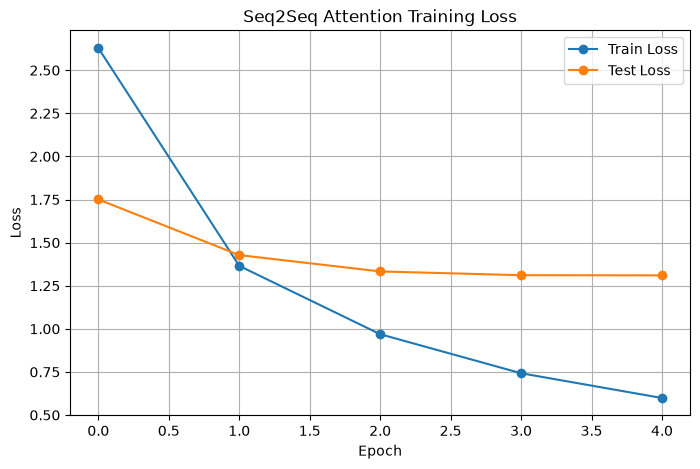


推理样例:
源句: ['incluso tomas tiene sus dudas .', '¿ quien sabe hablar frances mejor tom o mary ?', 'tom vino justo antes de la cena .']
预测: ['even tom has doubts .', 'who can speak french better or french ?', 'tom came just before dinner .']
参考: ['even tom has his doubts .', 'who can speak french better , tom or mary ?', 'tom came just before dinner .']


In [14]:
import math  # 数学函数，用于计算困惑度 exp
import torch  # PyTorch 核心库
import torch.nn as nn  # 神经网络模块
import matplotlib.pyplot as plt  # 绘图库
from torch.utils.data import DataLoader, Subset  # 数据加载相关

# =========================
# 1. 重新初始化 DataLoader
# =========================
BATCH_SIZE = 64  # 每批 64 条样本

train_loader = DataLoader(  # 训练集加载器
    train_dataset,  # 训练集 Dataset
    batch_size=BATCH_SIZE,  # 每批样本数
    shuffle=True,  # 训练集打乱
    collate_fn=collate_fn,  # 用自定义 collate_fn 组批
)

test_loader = DataLoader(  # 测试集加载器
    test_dataset,  # 测试集 Dataset
    batch_size=BATCH_SIZE,  # 每批样本数
    shuffle=False,  # 测试集不打乱
    collate_fn=collate_fn,  # 用自定义 collate_fn 组批
)

# =========================
# 2. 重新初始化模型
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 自动选择设备
print("当前设备:", device)  # 打印设备

model = Seq2SeqAttention(  # 创建 Seq2Seq 模型
    src_vocab_size=len(sp_tokenizer.word2idx),  # 源词表大小
    tgt_vocab_size=len(en_tokenizer.word2idx),  # 目标词表大小
    embed_size=128,  # 词嵌入维度
    hidden_size=256,  # 隐藏维度
    num_layers=1,  # 单层 GRU
    dropout=0.1,  # dropout 概率
    pad_idx=en_tokenizer.pad_idx,  # 英语 PAD id
    bos_idx=en_tokenizer.bos_idx,  # 英语 BOS id
    eos_idx=en_tokenizer.eos_idx,  # 英语 EOS id
).to(device)  # 把模型移到设备

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Adam 优化器


# =========================
# 3. 训练与评估函数
# =========================
def move_batch_to_device(batch, device):  # 该 batch 的全部张量
    """
    将 DataLoader 产出的一个 batch 中所有张量移动到指定设备。
    """
    return tuple(x.to(device) for x in batch)  # 每个张量都移到设备


def train_one_epoch(model, dataloader, optimizer, device):
    """
    训练一个 epoch。
    返回按有效 token 数加权后的平均训练 loss。
    """
    model.train()  # 训练模式
    total_loss = 0.0  # 累计加权损失
    total_tokens = 0  # 累计有效 token 数

    for batch_idx, batch in enumerate(dataloader, start=1):  # 逐 batch 训练
        encoder_input, decoder_input, decoder_output, encoder_mask, decoder_labels_mask = move_batch_to_device(  # 把 batch 各张量移到设备
            batch, device  # 该 batch 的全部张量
        )

        optimizer.zero_grad()  # 清空梯度
        logits, _ = model(  # 前向传播
            encoder_input,  # 编码器输入
            decoder_input,  # 解码器输入
            encoder_mask=encoder_mask,  # 编码器掩码
        )
        loss = sequence_loss(logits, decoder_output, decoder_labels_mask)  # 计算损失
        loss.backward()  # 反向传播

        optimizer.step()  # 更新参数

        # 计算当前 batch 中所有有效 token（即非 padding 部分）的数量
        valid_tokens = decoder_labels_mask.sum().item()
        # 将每个 batch 的 loss 按有效 token 数累加，便于最后加权平均
        total_loss += loss.item() * valid_tokens
        # 记录累计的有效 token 数量
        total_tokens += valid_tokens

        # 每训练 200 个 batch 或遍历完一个 epoch 时，打印一次当前的平均训练损失
        if batch_idx % 200 == 0 or batch_idx == len(dataloader):
            avg_loss = total_loss / total_tokens  # 当前平均损失
            print(f"  batch {batch_idx:>4}/{len(dataloader)}, train_loss={avg_loss:.4f}")  # 打印当前平均损失

    return total_loss / total_tokens  # 返回按 token 加权的平均损失


@torch.no_grad()  # 关闭梯度（装饰器）
def evaluate(model, dataloader, device):
    """
    在验证/测试集上评估模型。
    返回按有效 token 数加权后的平均 loss。
    """
    model.eval()  # 评估模式
    total_loss = 0.0  # 累计加权损失
    total_tokens = 0  # 累计有效 token 数

    for batch in dataloader:  # 逐 batch 评估
        encoder_input, decoder_input, decoder_output, encoder_mask, decoder_labels_mask = move_batch_to_device(  # 把 batch 各张量移到设备
            batch, device  # 该 batch 的全部张量
        )
        logits, _ = model(  # 前向传播
            encoder_input,  # 编码器输入
            decoder_input,  # 解码器输入
            encoder_mask=encoder_mask,  # 编码器掩码
        )
        loss = sequence_loss(logits, decoder_output, decoder_labels_mask)  # 计算损失
        # 计算当前 batch 中有效 token（非 padding 部分）的数量
        valid_tokens = decoder_labels_mask.sum().item()
        # 将当前 batch 的 loss 乘以有效 token 数，累加到总 loss 中
        total_loss += loss.item() * valid_tokens
        # 累加有效 token 的总数
        total_tokens += valid_tokens

    return total_loss / total_tokens  # 返回按 token 加权的平均损失


def fit(model, train_loader, test_loader, optimizer, device, epochs=5):
    """
    完整训练流程。
    每个 epoch 后在测试集上评估，并记录训练损失和测试损失。
    """
    history = {  # 记录训练/测试损失
        "train_loss": [],  # 训练损失列表
        "test_loss": [],  # 测试损失列表
    }

    for epoch in range(1, epochs + 1):  # 逐 epoch 训练
        print(f"\nEpoch {epoch}/{epochs}")  # 打印当前轮次
        train_loss = train_one_epoch(model, train_loader, optimizer, device)  # 训练一轮
        test_loss = evaluate(model, test_loader, device)  # 测试一轮

        history["train_loss"].append(train_loss)  # 记录训练损失
        history["test_loss"].append(test_loss)  # 记录测试损失

        # 计算训练集和测试集的困惑度（Perplexity，简称 PPL）
        train_ppl = math.exp(train_loss) if train_loss < 20 else float("inf")  # 训练困惑度
        test_ppl = math.exp(test_loss) if test_loss < 20 else float("inf")  # 测试困惑度

        print(  # 打印本轮指标
            f"Epoch {epoch} 完成: "  # 打印本轮指标
            f"train_loss={train_loss:.4f}, test_loss={test_loss:.4f}, "  # 训练/测试损失
            f"train_ppl={train_ppl:.2f}, test_ppl={test_ppl:.2f}"  # 训练/测试困惑度
        )

    return history  # 返回训练历史


# =========================
# 4. 开始训练并画损失曲线
# =========================
EPOCHS = 5  # 训练轮数
history = fit(model, train_loader, test_loader, optimizer, device, epochs=EPOCHS)  # 开始训练

plt.figure(figsize=(8, 5))  # 创建画布
plt.plot(history["train_loss"], label="Train Loss", marker="o")  # 训练损失曲线
plt.plot(history["test_loss"], label="Test Loss", marker="o")  # 测试损失曲线
plt.xlabel("Epoch")  # 横轴: 轮数
plt.ylabel("Loss")  # 纵轴: 损失
plt.title("Seq2Seq Attention Training Loss")  # 标题
plt.legend()  # 图例
plt.grid(True)  # 网格
plt.show()  # 显示图像

# =========================
# 5. 简单查看推理效果
# =========================
model.eval()
with torch.no_grad():  # 关闭梯度
    sample_batch = next(iter(test_loader))  # 取一个测试 batch
    encoder_input, decoder_input, decoder_output, encoder_mask, decoder_labels_mask = move_batch_to_device(  # 把 batch 各张量移到设备
        sample_batch, device  # 该 batch 的全部张量
    )
    pred_ids, infer_attn = model.infer(encoder_input[:3], encoder_mask=encoder_mask[:3], max_length=30)  # 取前 3 条做推理

print("\n推理样例:")  # 打印标题
print("源句:", sp_tokenizer.decode(encoder_input[:3].cpu().tolist()))  # 打印源句
print("预测:", en_tokenizer.decode(pred_ids.cpu().tolist()))  # 打印预测
print("参考:", en_tokenizer.decode(decoder_output[:3].cpu().tolist()))  # 打印参考

## 11. 注意力热力图可视化

把推理时每一步的注意力权重画成热力图，观察生成每个英文词时模型关注了哪些源语言词。


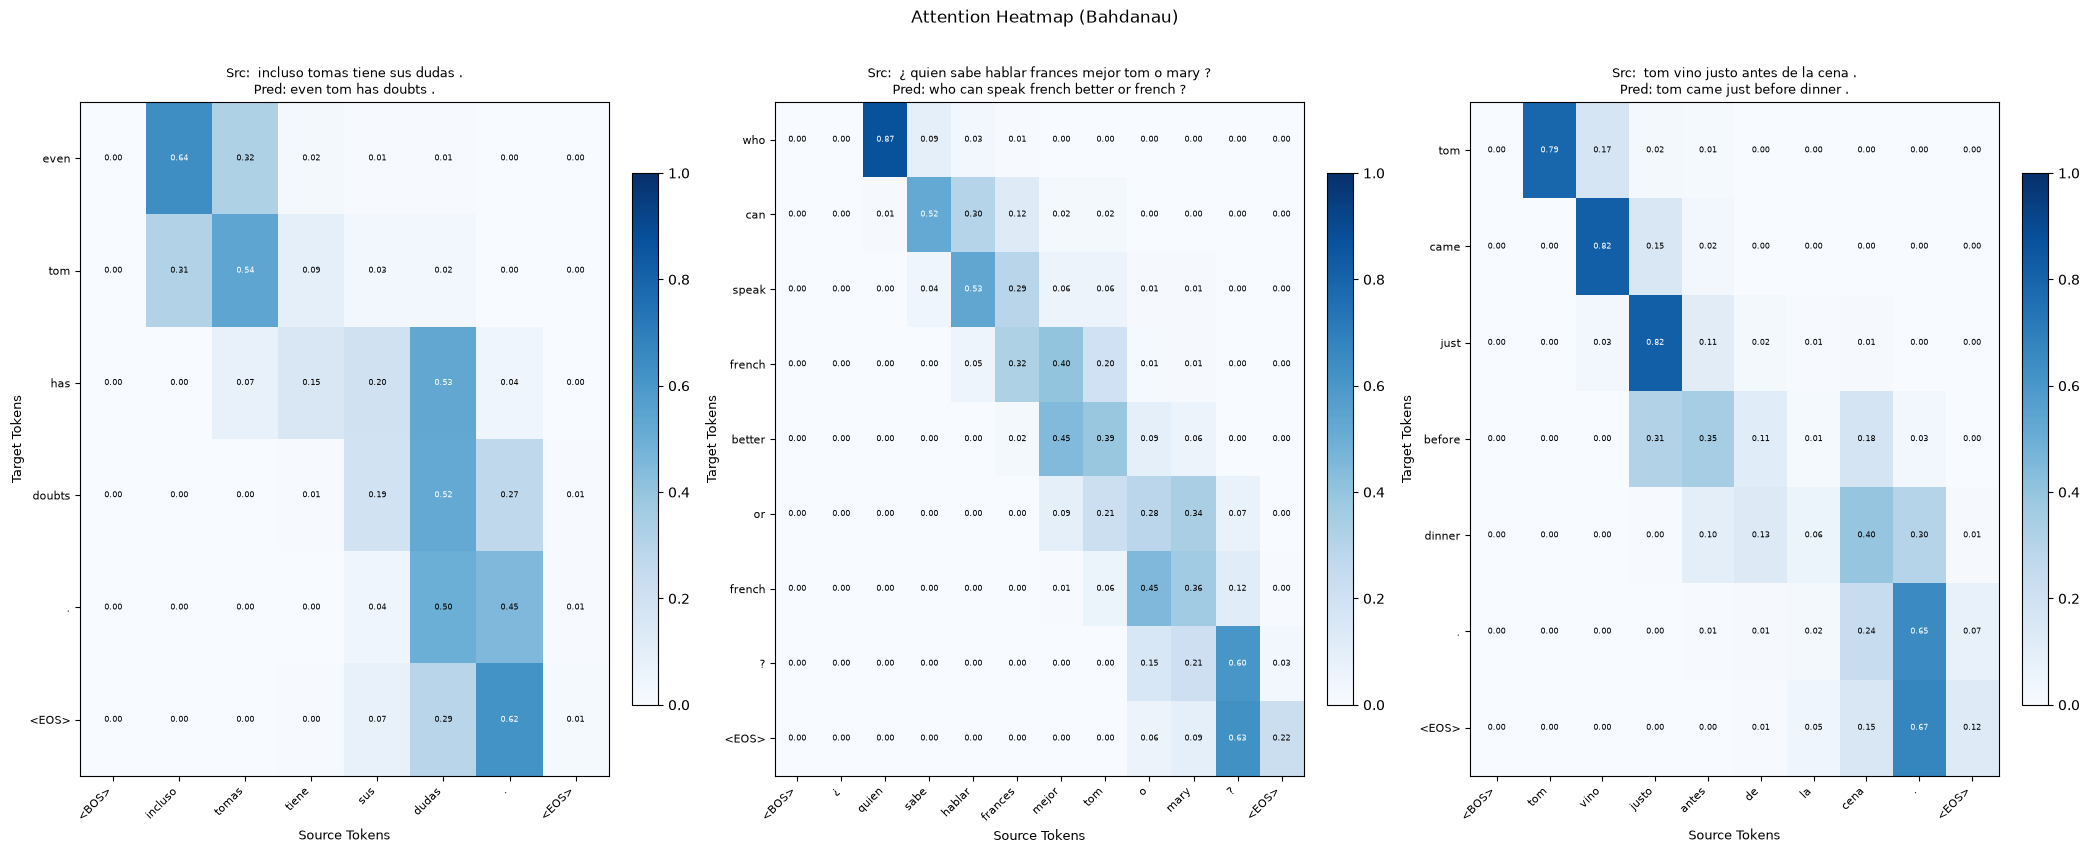

In [15]:
def get_tokens(tokenizer, ids):
    """
    将 token id 列表还原为 token 字符串列表，保留 BOS/EOS，去除 PAD。
    BOS 显示为 <BOS>，EOS 显示为 <EOS>。
    """
    result = []  # 收集 token 字符串
    for idx in ids:  # 逐 id 查表
        token = tokenizer.id2word.get(idx, tokenizer.unk_token)  # id → token（未知用 UNK）
        if token == tokenizer.pad_token:  # 遇到 PAD 停止
            # PAD 不在有效序列里，遇到就停
            break
        result.append(token)  # 收集有效 token
    return result  # 返回 token 字符串列表


def plot_attention_heatmap(attn_matrix, src_tokens, tgt_tokens, ax, title=""):
    """
    用 matplotlib 绘制单张注意力热力图。

    参数:
        attn_matrix: numpy array, shape (tgt_len, src_len)
        src_tokens: 源句 token 列表（含 <BOS>/<EOS>）
        tgt_tokens: 目标句 token 列表（含 <BOS>/<EOS>）
        ax: matplotlib Axes
        title: 子图标题
    """
    tgt_len, src_len = attn_matrix.shape  # 取注意力矩阵形状

    # 截取到实际 token 长度，去掉全零的多余行
    attn_matrix = attn_matrix[:len(tgt_tokens), :len(src_tokens)]

    im = ax.imshow(attn_matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1)  # 绘制热力图

    # x 轴：源句 token
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha="right", fontsize=8)  # 横轴标签（源词，倾斜显示）

    # y 轴：目标句 token
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_yticklabels(tgt_tokens, fontsize=8)  # 纵轴标签（目标词）

    # 每个格子内标注分数值
    for row in range(len(tgt_tokens)):
        for col in range(len(src_tokens)):  # 遍历每个源词
            val = attn_matrix[row, col]  # 取该格子的权重值
            # 分数深时用白字，浅时用黑字，对比度更好
            text_color = "white" if val > 0.5 else "black"
            ax.text(col, row, f"{val:.2f}", ha="center", va="center",  # 在格子内标注数值
                    fontsize=6, color=text_color)  # 字号与颜色

    ax.set_xlabel("Source Tokens", fontsize=9)  # 横轴标签
    ax.set_ylabel("Target Tokens", fontsize=9)  # 纵轴标签
    ax.set_title(title, fontsize=9)  # 子图标题

    # 颜色条
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


# ── 准备数据 ──────────────────────────────────────────
# N 由 infer_attn 实际 batch 大小决定，避免硬编码导致越界
N = infer_attn.shape[0]  # 实际 batch 大小

# encoder_input 含 BOS/EOS，保留特殊 token 以对应 encoder_outputs 各时间步
src_ids_list = encoder_input[:N].cpu().tolist()
pred_ids_list = pred_ids[:N].cpu().tolist()  # 预测 id 列表

# 源句 token 列表（保留 <BOS>/<EOS>），长度 = src_len
src_tokens_list = [get_tokens(sp_tokenizer, ids) for ids in src_ids_list]

# 预测句 token 列表：pred_ids 是 decoder 每步的输出 token（不含起始 BOS），
# 遇到 <PAD> 截断，行数 = 实际生成长度 <= dec_len
pred_tokens_list = [get_tokens(en_tokenizer, ids) for ids in pred_ids_list]

# ── 绘图 ─────────────────────────────────────────────
# squeeze=False 保证 N=1 时 axes 仍是二维数组，统一用 axes[0][idx] 取子图
fig, axes = plt.subplots(
    1, N,  # 一行 N 列子图
    figsize=(max(8, 7 * N), max(5, max(len(t) for t in pred_tokens_list) * 0.6 + 3)),  # 画布尺寸随 N 自适应
    squeeze=False,  # N=1 时 axes 仍为二维数组
)

for idx in range(N):  # 逐张绘制
    ax = axes[0][idx]  # squeeze=False 时统一取法
    attn = infer_attn[idx].cpu().numpy()  # (dec_len, src_len)
    src_tok = src_tokens_list[idx]  # 实际源句 token 列表
    tgt_tok = pred_tokens_list[idx]  # 实际预测 token 列表

    # 按真实 token 数截取，去掉 PAD 后的多余行/列
    attn_crop = attn[:len(tgt_tok), :len(src_tok)]

    src_str = " ".join(t for t in src_tok if t not in ("<BOS>", "<EOS>"))  # 源句去特殊符号
    pred_str = " ".join(t for t in tgt_tok if t not in ("<BOS>", "<EOS>"))  # 预测去特殊符号
    title = f"Src:  {src_str}\nPred: {pred_str}"  # 子图标题: 源句与预测

    plot_attention_heatmap(attn_crop, src_tok, tgt_tok, ax, title=title)  # 绘制该样本热力图

plt.suptitle("Attention Heatmap (Bahdanau)", fontsize=12, y=1.01)  # 总标题
plt.tight_layout()  # 调整布局
plt.show()  # 显示图像

## 12. BLEU 指标评估

用 nltk 计算语料级 BLEU 与句级 BLEU，量化翻译质量。


In [17]:
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction  # nltk BLEU 计算


def ids_to_word_list(tokenizer, ids):
    """
    将 token id 列表转为词列表，去除 PAD/BOS/EOS 等特殊符号。
    用于 BLEU 计算时的 reference / hypothesis 输入。
    """
    words = []  # 收集词
    special = {tokenizer.pad_token, tokenizer.bos_token, tokenizer.eos_token}  # 需去除的特殊符号
    for idx in ids:  # 逐 id 查表
        token = tokenizer.id2word.get(idx, tokenizer.unk_token)  # id → token
        if token in special:  # 特殊符号跳过
            continue  # 跳过
        words.append(token)  # 收集正常词
    return words  # 返回词列表


@torch.no_grad()  # 关闭梯度（装饰器）
def evaluate_bleu(model, dataloader, device, max_length=30):
    """
    在测试集上用 model.infer 自回归解码，计算 BLEU 指标。

    参数:
        model: 训练好的 Seq2SeqAttention 模型
        dataloader: 测试集 DataLoader
        device: 运行设备
        max_length: infer 最大解码步数

    返回:
        corpus_bleu_score: 语料级 BLEU（corpus_bleu）
        avg_sentence_bleu: 句级 BLEU 的平均值
        references: 参考译文词列表，每项为 [ref_tokens]
        hypotheses: 预测译文词列表
    """
    model.eval()  # 评估模式
    smoothie = SmoothingFunction().method1  # 平滑方法（避免 0 分）
    weights = (0.25, 0.25, 0.25, 0.25)  # 4-gram BLEU

    references = []  # 参考译文列表
    hypotheses = []  # 预测译文列表
    sentence_bleu_scores = []  # 句级 BLEU 列表

    for batch_idx, batch in enumerate(dataloader, start=1):  # 逐 batch 评估
        encoder_input, _, decoder_output, encoder_mask, _ = move_batch_to_device(  # 取需要的张量
            batch, device  # 该 batch 的全部张量
        )

        # 与推理样例一致：对整批样本做 infer
        pred_ids, _ = model.infer(
            encoder_input,  # 编码器输入
            encoder_mask=encoder_mask,  # 编码器掩码
            max_length=max_length,  # 最大解码步数
        )

        pred_ids_list = pred_ids.cpu().tolist()  # 预测 id 列表
        ref_ids_list = decoder_output.cpu().tolist()  # 参考 id 列表

        for pred_ids_i, ref_ids_i in zip(pred_ids_list, ref_ids_list):  # 逐条样本
            hyp = ids_to_word_list(en_tokenizer, pred_ids_i)  #预测结果
            ref = ids_to_word_list(en_tokenizer, ref_ids_i)  #标准答案

            references.append([ref])  # corpus_bleu 要求每条样本是 [ref1, ref2, ...]
            hypotheses.append(hyp)  # 收集预测词列表
            sentence_bleu_scores.append(  # 计算句级 BLEU
                sentence_bleu([ref], hyp, weights=weights, smoothing_function=smoothie)  # 句级 BLEU 得分
            )

        if batch_idx % 50 == 0 or batch_idx == len(dataloader):  # 每 50 个 batch 打印进度
            print(f"  已评估 batch {batch_idx}/{len(dataloader)}")  # 打印进度

    # 这个的作用是计算整个语料库级别的 BLEU 分数（corpus_bleu），用于评估模型在所有预测结果上的整体翻译质量。
    corpus_bleu_score = corpus_bleu(
        references, hypotheses, weights=weights, smoothing_function=smoothie  # 传入参考/预测与平滑参数
    )
    avg_sentence_bleu = sum(sentence_bleu_scores) / len(sentence_bleu_scores)  # 句级 BLEU 平均
    return corpus_bleu_score, avg_sentence_bleu, references, hypotheses  # 返回指标与语料


# =========================
# 测试集 BLEU 评估
# =========================
print("开始计算测试集 BLEU ...")  # 打印提示
corpus_bleu_score, avg_sentence_bleu, all_refs, all_hyps = evaluate_bleu(  # 开始评估
    model, test_loader, device, max_length=30  # 模型/测试集/设备/长度
)

print(f"\n测试集样本数: {len(all_hyps)}")  # 打印样本数
print(f"Corpus BLEU (4-gram): {corpus_bleu_score:.4f}")  # 打印语料级 BLEU
print(f"Average Sentence BLEU (4-gram): {avg_sentence_bleu:.4f}")  # 打印句级 BLEU

# 展示前 3 条样例，便于对照推理效果
print("\nBLEU 评估样例（前 3 条）:")  # 打印标题
for i in range(min(3, len(all_hyps))):  # 展示前 3 条
    print(f"[{i + 1}] 预测: {' '.join(all_hyps[i])}")  # 打印预测
    print(f"    参考: {' '.join(all_refs[i][0])}")  # 打印参考
    print("-" * 40)  # 分隔线

开始计算测试集 BLEU ...
  已评估 batch 50/186
  已评估 batch 100/186
  已评估 batch 150/186
  已评估 batch 186/186

测试集样本数: 11897
Corpus BLEU (4-gram): 0.4462
Average Sentence BLEU (4-gram): 0.4174

BLEU 评估样例（前 3 条）:
[1] 预测: even tom has doubts .
    参考: even tom has his doubts .
----------------------------------------
[2] 预测: who can speak french better or french ?
    参考: who can speak french better , tom or mary ?
----------------------------------------
[3] 预测: tom came just before dinner .
    参考: tom came just before dinner .
----------------------------------------


## 13. 总结

### 模型关键点

- Encoder：单向 GRU，把源句编码成每个时间步的隐藏状态。
- Attention：Bahdanau 加法注意力，对每个输出词动态选择相关源语言位置，避免把整句压缩成固定向量。
- Decoder：带注意力的 GRU，每步用 [词嵌入; context] 更新状态，再用 [GRU 输出; context] 预测词表 logits。
- 训练：Teacher Forcing + 忽略 PAD 的交叉熵，按有效 token 加权平均。
- 推理：从 BOS 开始 greedy 解码，遇到 EOS 停止。

### 可改进方向

1. 使用双向 GRU 或多层结构，增强源句表示能力。
2. 推理阶段使用 beam search，缓解贪心解码的局部最优。
3. 引入 BPE/Subword 分词，缓解未知词问题。
4. 换用 Transformer 架构，并扩大数据与训练轮数。
